In [4]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from askmydocs.loader import load_document
from askmydocs.splitter import split_documents
from askmydocs.embedder import embed_texts
from pathlib import Path

In [5]:
pdf_path = Path("../data/uploads/RGPD.pdf")

pages = load_document(pdf_path)
chunks = split_documents(pages)
print(f"{len(chunks)} chunks chargés")

texts = [c["text"] for c in chunks]
pages_num = [c["page"] for c in chunks]

626 chunks chargés


In [6]:
print("Calcul des embeddings... (peut prendre 1-2 min)")
embeddings = np.array(embed_texts(texts))
print(f"Shape des embeddings : {embeddings.shape}")
# (nombre de chunks, 384)

Calcul des embeddings... (peut prendre 1-2 min)
⏳ Chargement du modèle d'embedding 'paraphrase-multilingual-MiniLM-L12-v2'...


/home/lilian/askmypdf/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Modèle chargé
Shape des embeddings : (626, 384)


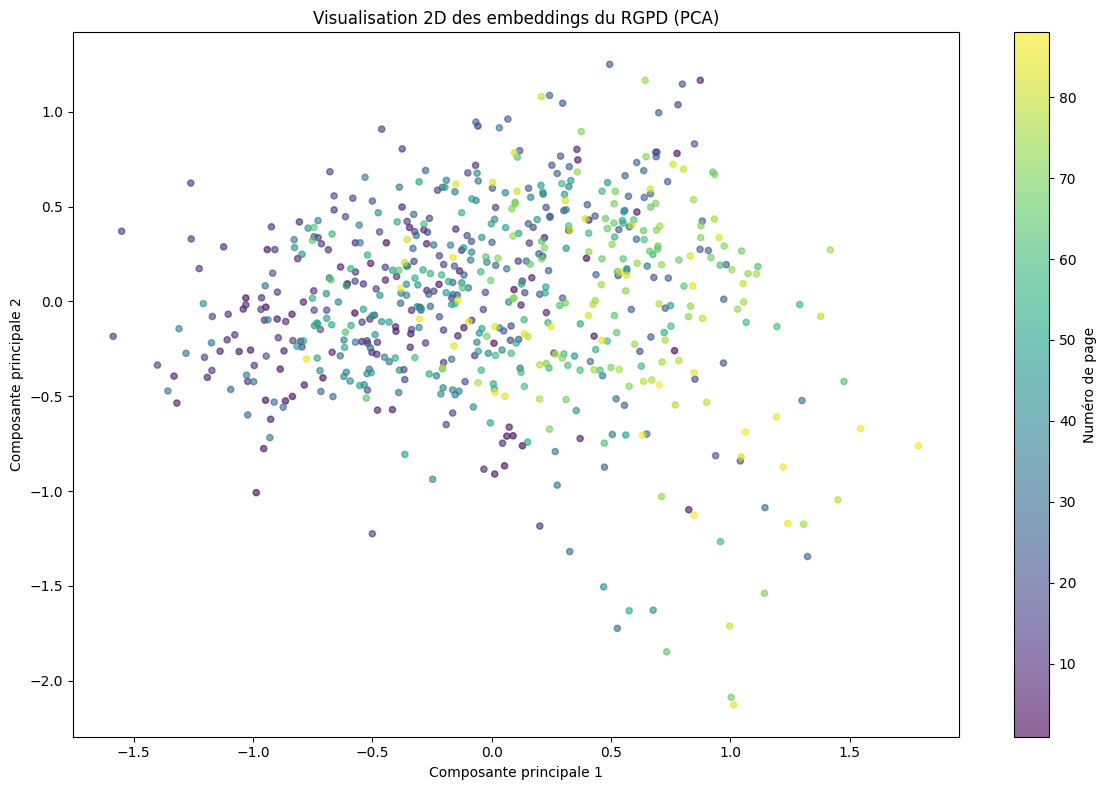

In [8]:
# PCA : on projette les 384 dimensions sur 2 pour pouvoir visualiser
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=pages_num, cmap="viridis",
    alpha=0.6, s=20
)
plt.colorbar(scatter, label="Numéro de page")
plt.title("Visualisation 2D des embeddings du RGPD (PCA)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.tight_layout()
plt.savefig("../docs/embeddings_pca.png", dpi=150)  # pour le README
plt.show()

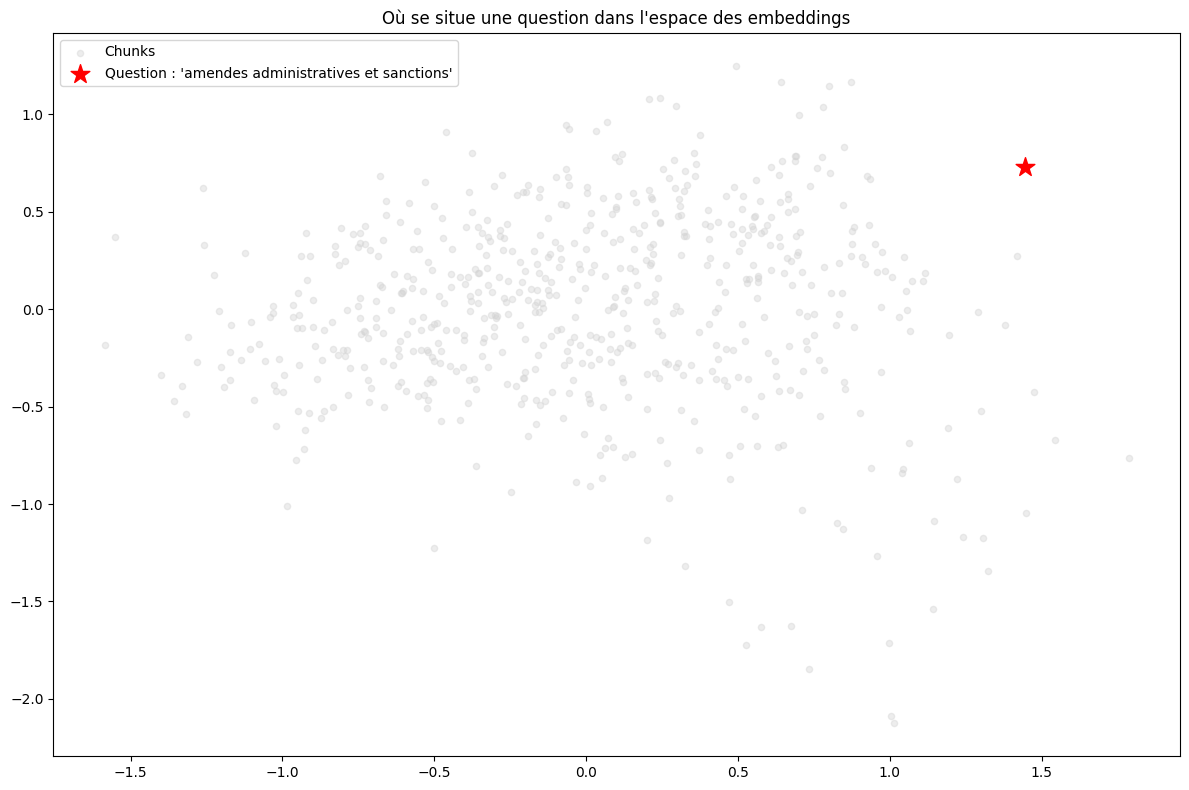

In [9]:
from askmydocs.embedder import embed_query

question = "amendes administratives et sanctions"
q_vector = np.array(embed_query(question))
q_coords = pca.transform([q_vector])

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], c="lightgray", alpha=0.4, s=20, label="Chunks")
plt.scatter(q_coords[:, 0], q_coords[:, 1], c="red", s=200, marker="*",
            label=f"Question : '{question}'")
plt.title("Où se situe une question dans l'espace des embeddings")
plt.legend()
plt.tight_layout()
plt.show()